# Pow(x, n)

## Question
---

Implement pow(x, n), which calculates x raised to the power n (i.e., $x^n$).



Example 1:

* Input: x = 2.00000, n = 10
* Output: 1024.00000

Example 2:

* Input: x = 2.10000, n = 3
* Output: 9.26100

Example 3:

* Input: x = 2.00000, n = -2
* Output: 0.25000
* Explanation: 2-2 = 1/22 = 1/4 = 0.25

## Constraints
* -100.0 < x < 100.0
* $-2^{31}$ <= n <= $2^{31}$-1
* n is an integer.
* Either x is not zero or n > 0.
* $-10^4$ <= $x^n$ <= $10^4$
---

## Solution
---
This question firstly i solved it with basic recursion (linear recursion)

## Code
```
class Solution {
    public double helper(double base,int power){
        if(power == 0){
            return 1;
        }
        if(power > 0){
            return base * helper(base,power -1);
        }else{
            return 1/(base)*helper(base,power + 1);
        }
    }
    public double myPow(double x, int n) {
        if(x == 0 || x == 1){
            return x;
        }else{
            return helper(x,n);
        }
        
    }
}
```

while submitting the above code i get an runtime error ....
* i get this beacause i am reducing my recursive calls by 1 .
* now suppose i get a testcase as --
   * x = 2  n = 20000000
   * this many recursive calls will give me stackoverflow error.
  

To reduce this you have understand a tiny bit mathematical concept -
* $x^n$ = $x^{n/2}$ * $x^{n/2}$         {if n = even}
  * for example -- $x^8$ = $x^4$ * $x^4$

*  $x^n$ = $x^{n-1/2}$ * $x^{n-1/2}$ * x       {if n = odd}
    * for example -- $x^{17}$ = $x^8$ * $x^8$ * x



# actual correct code


```
class Solution {
    public double helper(double base,long power){
        if(power == 0){
            return 1;
        }
        if(power > 0 && power % 2 == 0){
            double half_part = helper(base,power/2);
            return half_part * half_part;
            }
        if(power > 0 && power % 2 !=0){
            double even_part = helper(base,(power - 1)/2);
            return base * even_part * even_part;
        }
        if(power < 0 && power % 2 == 0){
            double half_part = helper(base, (-power)/2);
            return 1/(half_part*half_part);
        }
        if(power < 0 && power % 2 != 0){
            double even_part = helper(base,(-power - 1)/2);
            return 1/(even_part * even_part*base);
        }

      return 0.0;  
    }
    public double myPow(double x, int n) {
        if(x == 0 || x == 1){
            return x;
        }else{
            long N = (long) n;
            return helper(x,N);
        }
        
    }
}
```



# understanding of the code

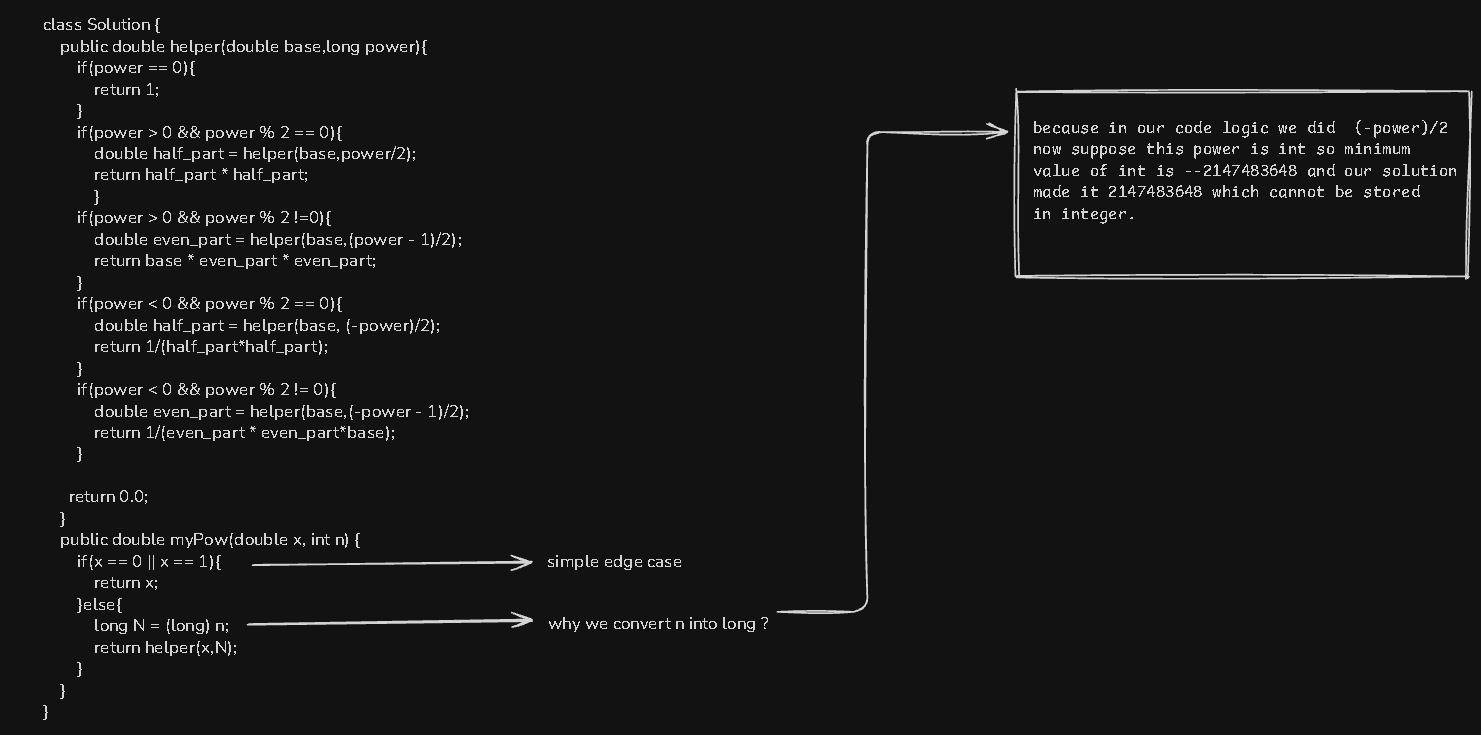

# code flow

we do code flow for
* x = 2 ___________n = 200
* x = 3 ___________n = -17

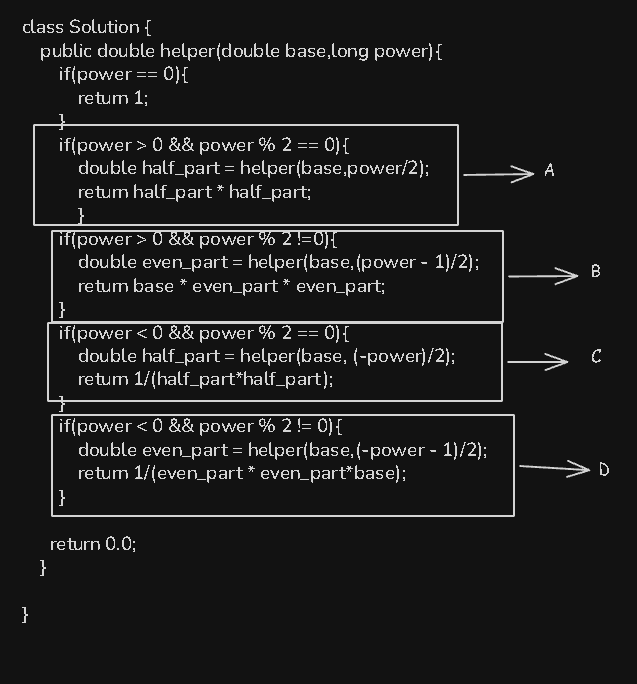

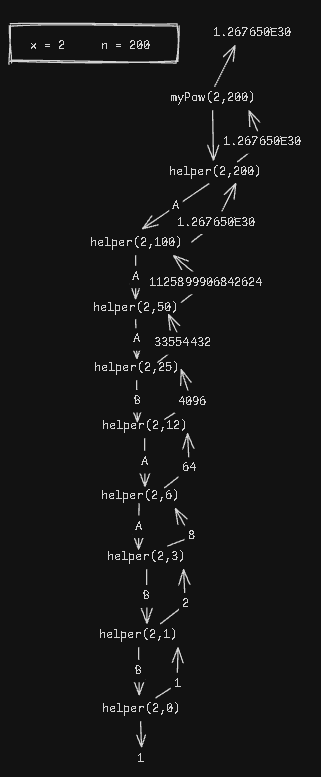

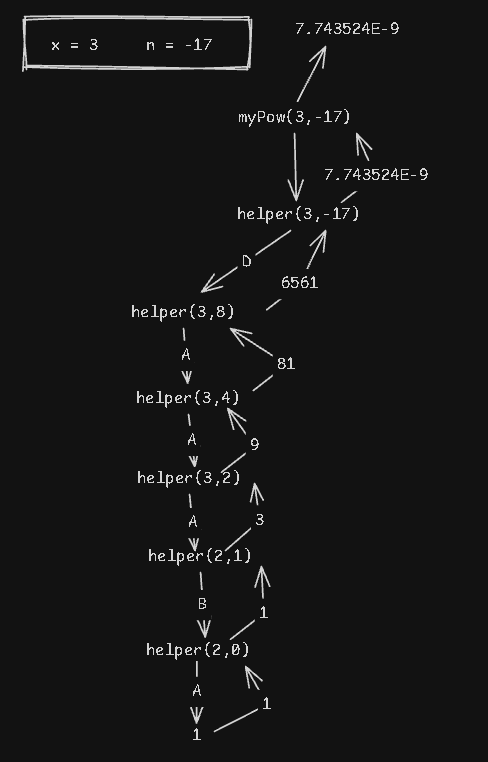

time complexity = $O(log(n))$

space complexity = $O(log(n))$
